# Image Classification — Deteksi Jenis Sampah
### Convolutional Neural Network (CNN)


##  1. Install & Import Library

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
from google.colab import files
files.upload()

# Download dataset
!kaggle datasets download -d farzadnekouei/trash-type-image-dataset
!unzip -q trash-type-image-dataset.zip -d data/


Saving archive (1).zip to archive (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset
License(s): unknown
100% 40.9M/40.9M [00:03<00:00, 13.0MB/s]

⚠️  Uncomment kode di atas sesuai environment yang digunakan.
📁 Pastikan struktur folder data seperti berikut:

data/
├── train/
│   ├── cardboard/
│   ├── glass/
│   ├── metal/
│   ├── paper/
│   ├── plastic/
│   └── trash/
└── test/
    ├── cardboard/
    ├── glass/
    ├── metal/
    ├── paper/
    ├── plastic/
    └── trash/



###  Konfigurasi Parameter



In [ ]:
# ===== KONFIGURASI =====
IMG_SIZE    = (128, 128)   # Ukuran gambar input
BATCH_SIZE  = 32           # Jumlah gambar per batch
EPOCHS      = 20           # Jumlah epoch training
SEED        = 42           # Seed untuk reproducibility

# Path dataset — sesuaikan dengan path di environment Anda
TRAIN_DIR   = 'data/TrashType_Image_Dataset/train'
TEST_DIR    = 'data/TrashType_Image_Dataset/test'

# Kelas sampah
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASS_NAMES)

print(f"📌 Image Size  : {IMG_SIZE}")
print(f"📌 Batch Size  : {BATCH_SIZE}")
print(f"📌 Epochs      : {EPOCHS}")
print(f"📌 Num Classes : {NUM_CLASSES}")
print(f"📌 Classes     : {CLASS_NAMES}")

📌 Image Size  : (128, 128)
📌 Batch Size  : 32
📌 Epochs      : 20
📌 Num Classes : 6
📌 Classes     : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
TRAIN_DIR = 'data/TrashType_Image_Dataset'
TEST_DIR = 'data/TrashType_Image_Dataset'

# Data Augmentation untuk Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2        # 20% dari train sebagai validasi
)

# Untuk Test/Validasi — hanya rescale, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data Training
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# Load data Validasi
val_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

# Load data Testing
test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Train samples    : {train_data.samples}")
print(f"✅ Validation samples: {val_data.samples}")
print(f"✅ Test samples      : {test_data.samples}")
print(f"✅ Class indices     : {train_data.class_indices}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Found 2527 images belonging to 6 classes.

✅ Train samples    : 2024
✅ Validation samples: 503
✅ Test samples      : 2527
✅ Class indices     : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


##  Visualisasi Sampel Data

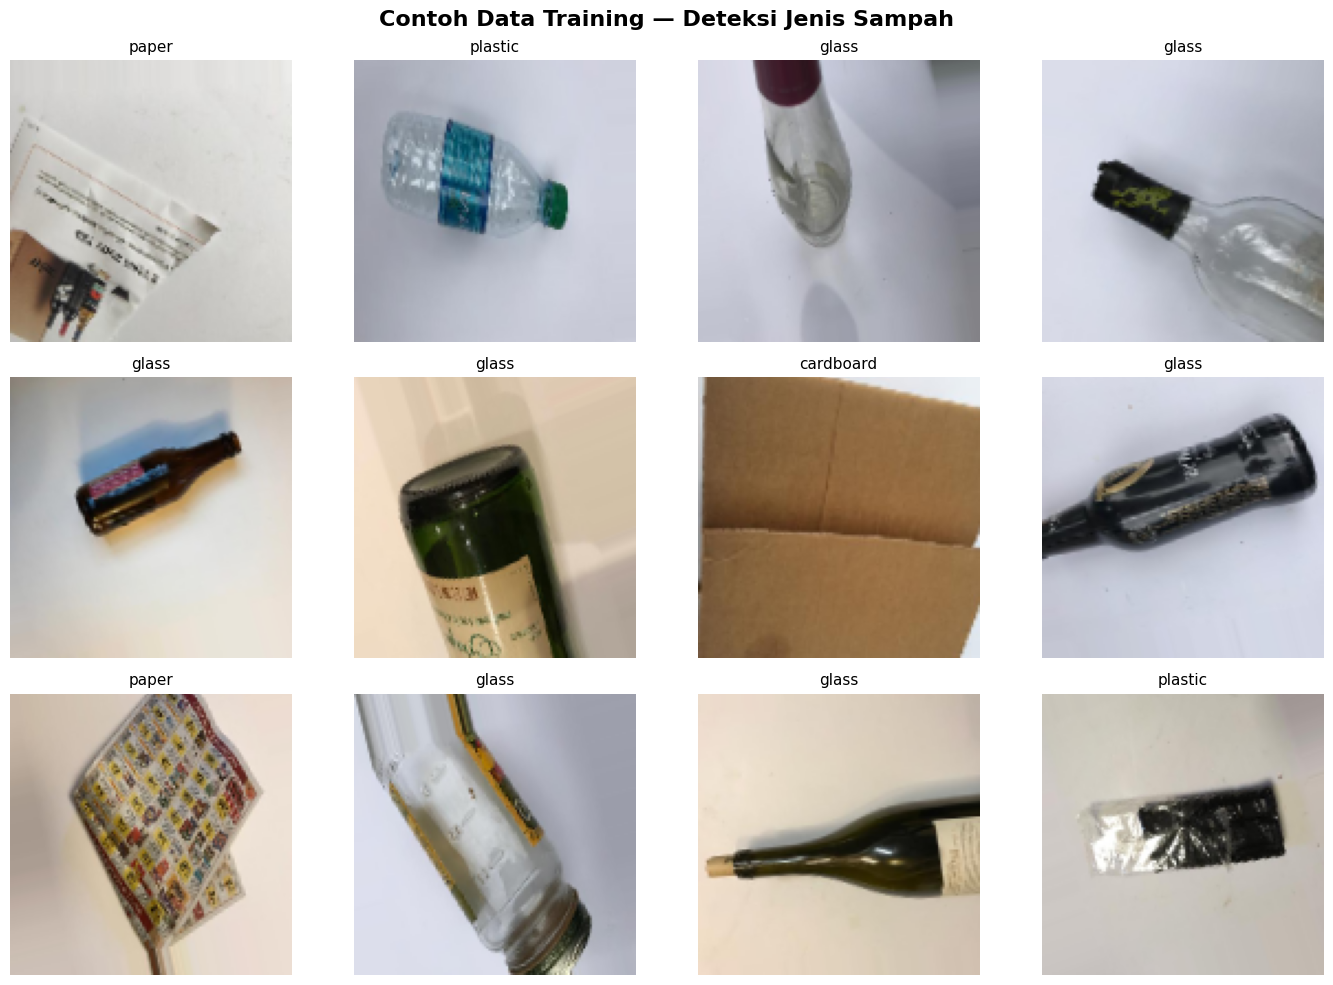

In [ ]:
# Ambil satu batch gambar
images, labels = next(iter(train_data))

# Mapping index ke nama kelas
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

# Tampilkan 12 gambar pertama
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Contoh Data Training — Deteksi Jenis Sampah', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        label_idx = np.argmax(labels[i])
        ax.set_title(f"{idx_to_class[label_idx]}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Membangun Model CNN

Arsitektur CNN sesuai materi:
```
Input → [Conv2D + ReLU + MaxPooling] × 3 → Flatten → Dense → Output (Softmax)
```

In [ ]:
def build_cnn_model(num_classes, input_shape=(128, 128, 3)):
    """
    Membangun model CNN untuk klasifikasi gambar sampah.

    Arsitektur:
    - 3 blok Convolution + ReLU + MaxPooling
    - BatchNormalization untuk stabilitas training
    - Dropout untuk mencegah overfitting
    - Fully Connected Layer (MLP)
    - Output: Softmax untuk multi-class classification
    """
    model = Sequential([
        # ===== Blok 1: Convolution Layer =====
        # Mendeteksi fitur dasar: tepi, garis, sudut
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape, name='conv1'),
        BatchNormalization(),
        MaxPooling2D(2, 2, name='pool1'),

        # ===== Blok 2: Convolution Layer =====
        # Mendeteksi fitur menengah: tekstur, pola
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        BatchNormalization(),
        MaxPooling2D(2, 2, name='pool2'),

        # ===== Blok 3: Convolution Layer =====
        # Mendeteksi fitur kompleks: bentuk objek
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        BatchNormalization(),
        MaxPooling2D(2, 2, name='pool3'),

        # ===== Flatten =====
        # Mengubah 3D feature map → vektor 1D
        Flatten(name='flatten'),

        # ===== Fully Connected Layer (MLP) =====
        Dense(256, activation='relu', name='fc1'),
        Dropout(0.5),          # Mencegah overfitting
        Dense(128, activation='relu', name='fc2'),
        Dropout(0.3),

        # ===== Output Layer =====
        # Softmax: probabilitas tiap kelas sampah
        Dense(num_classes, activation='softmax', name='output')
    ])

    return model


# Buat model
model = build_cnn_model(NUM_CLASSES)



## Compile Model

In [ ]:
model.compile(
    optimizer='adam',                        # Adaptive learning rate
    loss='categorical_crossentropy',         # Loss untuk multi-class
    metrics=['accuracy']
)

print("✅ Model berhasil di-compile!")
print(f"   Optimizer : Adam")
print(f"   Loss      : Categorical Crossentropy")
print(f"   Metrics   : Accuracy")

✅ Model berhasil di-compile!
   Optimizer : Adam
   Loss      : Categorical Crossentropy
   Metrics   : Accuracy


## Training Model

Menggunakan callbacks:
- **EarlyStopping**: berhenti jika val_loss tidak membaik
- **ReduceLROnPlateau**: kurangi learning rate jika stagnan

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Training
print("🚀 Memulai training...\n")
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training selesai!")

🚀 Memulai training...

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.2900 - loss: 5.0077 - val_accuracy: 0.1909 - val_loss: 5.4875 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.2940 - loss: 1.7146 - val_accuracy: 0.2048 - val_loss: 3.4281 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.2950 - loss: 1.6663 - val_accuracy: 0.1571 - val_loss: 4.4092 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.3004 - loss: 1.6401 - val_accuracy: 0.1630 - val_loss: 3.0428 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.2955 - loss: 1.6624 - val_accuracy: 0.1869 - val_loss: 3.5027 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.2708 - loss: 1.6860 - val_accuracy: 0.2604 - val_loss: 1.8479 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.2569 -

## Visualisasi Hasil Training

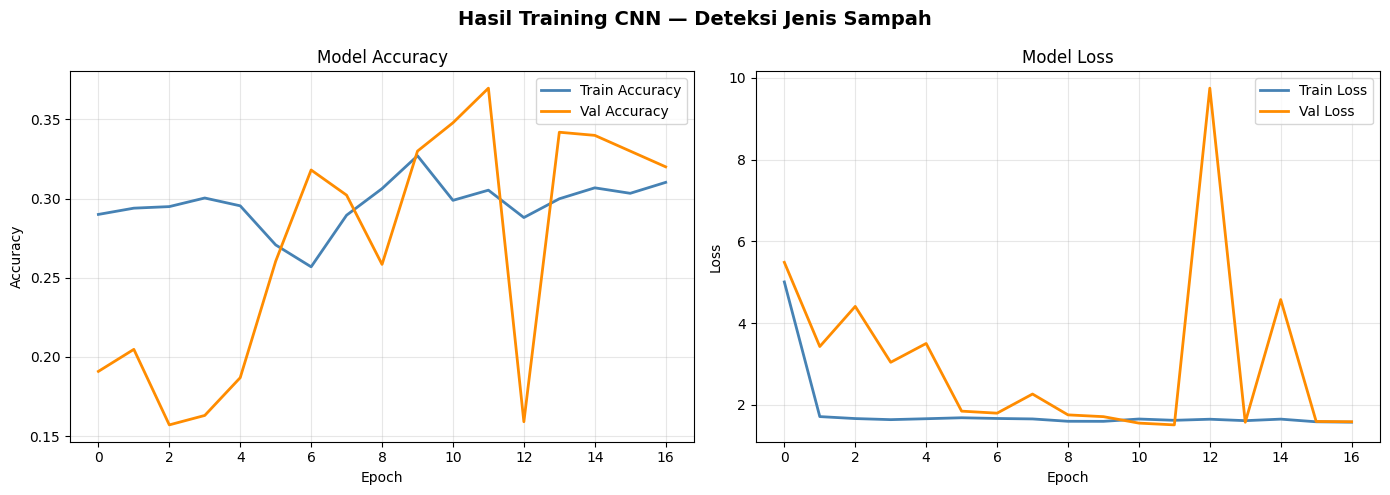

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Hasil Training CNN — Deteksi Jenis Sampah', fontsize=14, fontweight='bold')

    # Plot Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue',  linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorange', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
# Evaluasi pada test set
print("📊 Evaluasi pada Test Set:")
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n✅ Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"✅ Test Loss     : {test_loss:.4f}")

📊 Evaluasi pada Test Set:
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 480ms/step - accuracy: 0.3455 - loss: 1.5143

✅ Test Accuracy : 0.3455 (34.55%)
✅ Test Loss     : 1.5143


##  Simpan & Load Model

In [ ]:
# Simpan model
model.save('cnn_trash_classifier.h5')
print("✅ Model tersimpan sebagai: cnn_trash_classifier.h5")

# Cara load model kembali:
# from tensorflow.keras.models import load_model
# model = load_model('cnn_trash_classifier.h5')
# print('✅ Model berhasil dimuat!')

✅ Model tersimpan sebagai: cnn_trash_classifier.h5
